In [10]:
import numpy as np
import matplotlib.pyplot as plt

events = np.load('runs/20260819-110056/events.npy')
triggers = np.load('runs/20260819-110056/triggers.npy')

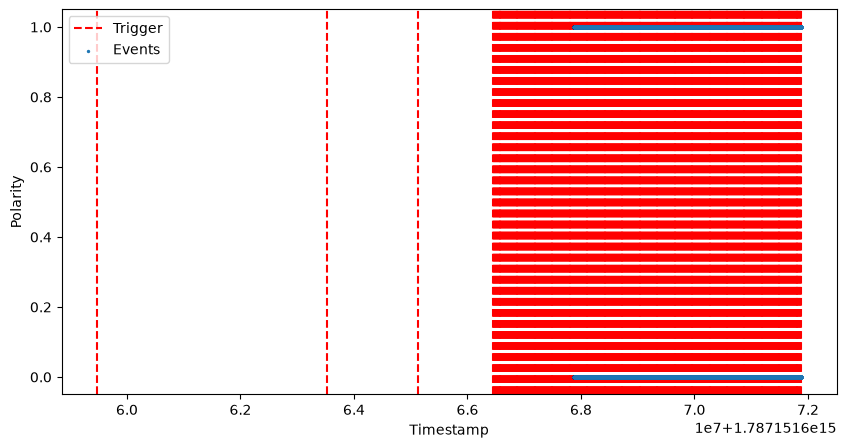

In [28]:
# plot the timestamps of the events and triggers
event_timestamps = events[:]['timestamp']
event_polarity = events[:]['polarity']

plt.figure(figsize=(10, 5))
# plot the triggers as vertical lines
for trigger in triggers:
    plt.axvline(x=trigger, color='r', linestyle='--', ymin=0, ymax=1, zorder=0, label='Trigger' if trigger == triggers[0] else "")
plt.scatter(event_timestamps, event_polarity, s=2, zorder=1, label='Events')
plt.xlabel('Timestamp')
plt.ylabel('Polarity')
plt.legend()
plt.show()

In [1]:
from dmdcontrol.patterns import pack_count_sequence_frames, pack_sequence_frames, _decimal_number_display_masks
import numpy as np

In [4]:
frames_a = pack_count_sequence_frames(
    1,
    64,
    1,
    width=1920,
    height=1080,
    size_px=300,
    count_blank_between_frames=True,
)

In [5]:
fm = np.zeros((64, 32, 32), dtype=np.uint8)
for count in range(1, 65):
    count_mask = _decimal_number_display_masks(
        (count,),
        width=32,
        height=32,
        size_px=32,
    )
    fm[count - 1] = count_mask[0]
    
frames_b = pack_sequence_frames(fm)

In [6]:
np.asarray(frames_a).shape, np.asarray(frames_b).shape

((128, 1080, 1920, 3), (256, 32, 32, 3))

In [7]:
frames_a[0].dtype, frames_b[0].dtype

(dtype('uint8'), dtype('uint8'))

In [8]:
frames_b.shape, frames_b.max(), frames_b.min()

((256, 32, 32, 3), np.uint8(1), np.uint8(0))

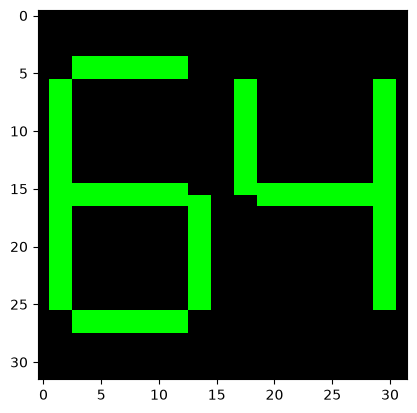

In [9]:
import matplotlib.pyplot as plt

plt.imshow(frames_b[-4,:,:,:]*255, cmap='gray')
plt.show()

In [10]:
from dmdcontrol.patterns import generate_dot_frame

k = generate_dot_frame()

In [11]:
k[:,:,2].max()

np.uint8(255)

In [12]:
k.shape

(1080, 1920, 3)

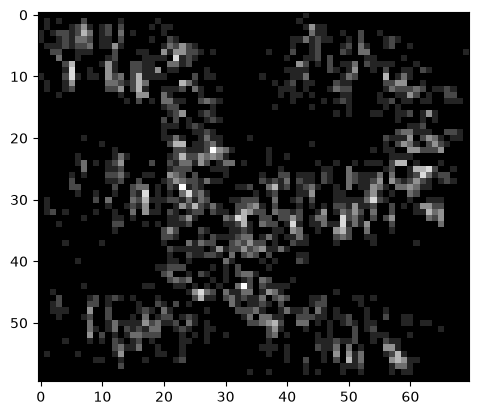

In [11]:
import numpy as np
import matplotlib.pyplot as plt

frame = 'runs/20260820-174745/frames/frame_133.png'
img = plt.imread(frame)
plt.imshow(img[100:160,145:215], cmap='gray')

$$S_{eff} = \frac{z \Phi_{pt} \Delta}{F_{pt} (u+z)}$$

In [2]:
cam_pt = 18.5e-6
decimation = 1
dmd_pt = 7.6e-6
u = 90e-3
z = 80e-3

stride = (z * cam_pt * decimation) / (dmd_pt * (u + z))
print(f'stride: {stride:.2f} pixels')

stride: 1.15 pixels
